In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

## Setup

In [11]:
def show_image(image, figsize=(12, 8), dpi=100):
    plt.figure(figsize=figsize, dpi=dpi)
    plt.imshow(image)
    plt.axis("off")
    plt.show()

In [67]:
def filter_lines_by_angle(lines, angle_thresh=15):
    if lines is None:
        return None, [], []
    horizontal = []
    vertical = []
    others = []
    for line in lines:
        x1, y1, x2, y2 = line[0]
        # Since both arguments to arctan2 are abs(...), they're always non-negative. That means the result is always in [0, 90] degrees: 
        angle = np.degrees(np.arctan2(abs(y2 - y1), abs(x2 - x1)))
        if angle <= angle_thresh:
            horizontal.append(line)
        elif angle >= 90 - angle_thresh:
            vertical.append(line)
        else:
            others.append(line)
    if not others:
        return np.empty((0, 1, 4), dtype=np.int32), horizontal, vertical
    return others, horizontal, vertical

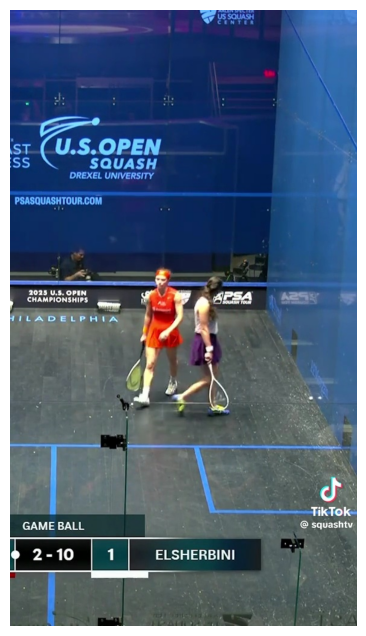

In [68]:
image = cv2.imread("../data/samples/frame_000216.jpg")
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

show_image(image_rgb)

## Preprocessing

In [69]:
gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)

# GaussianBlur to reduce noise and help edge detection
blurred = cv2.GaussianBlur(gray, (5, 5), 0)

edges = cv2.Canny(blurred, 50, 150)

In [70]:

# Morphological closing (dilate -> erode) to bridge gaps in edge segments
kernel = np.ones((5, 5), np.uint8)
dilated = cv2.dilate(edges, kernel, iterations=1)
eroded = cv2.erode(dilated, kernel, iterations=1)

## Contour Detection

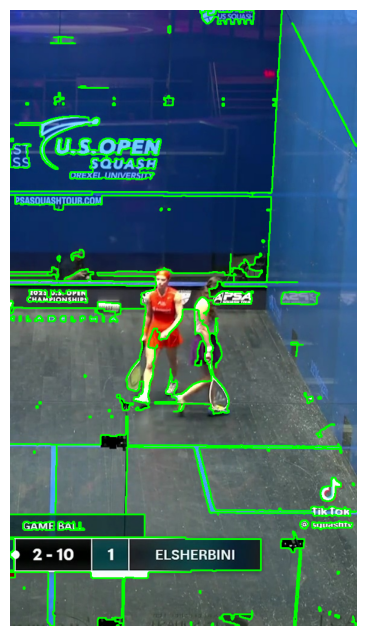

In [85]:
# Find contours in the eroded image
contours, _ = cv2.findContours(eroded, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
vis = image_rgb.copy()
vis = cv2.drawContours(vis, contours, -1, (0, 255, 0), 2)  # green, thickness 2
show_image(vis)

## Line Detection (Hough Transform)

In [86]:
# Create a blank image to draw the lines
line_image = np.zeros_like(image_rgb)

In [87]:
# Use Hough Line Transform to detect lines
lines = cv2.HoughLinesP(eroded, 1, np.pi / 180, threshold=50, minLineLength=50, maxLineGap=10)

In [88]:
filtered_out_lines, horizontal_lines, vertical_lines = filter_lines_by_angle(lines, angle_thresh=10)
print(f"Total lines: {len(lines)}, Others: {len(other_lines)}, Horizontal: {len(horizontal_lines)}, Vertical: {len(vertical_lines)}")

Total lines: 249, Others: 50, Horizontal: 174, Vertical: 25


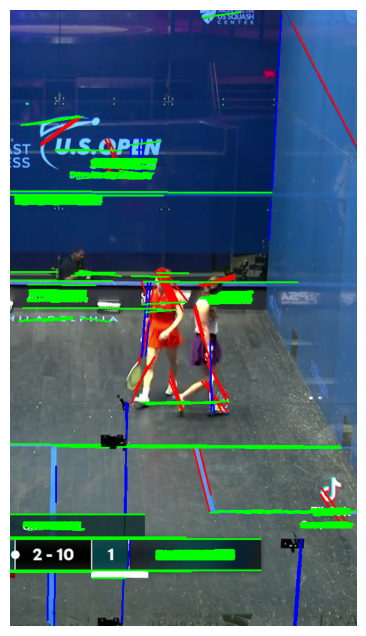

In [91]:
color_vis = image_rgb.copy()
for line in filtered_out_lines:
    x1, y1, x2, y2 = line[0]
    cv2.line(color_vis, (x1, y1), (x2, y2), (255, 0, 0), 2)  # red = filtered_out
for line in vertical_lines:
    x1, y1, x2, y2 = line[0]
    cv2.line(color_vis, (x1, y1), (x2, y2), (0, 0, 255), 2)  # blue = vertical
for line in horizontal_lines:
    x1, y1, x2, y2 = line[0]
    cv2.line(color_vis, (x1, y1), (x2, y2), (0, 255, 0), 2)  # green = horizontal
show_image(color_vis)